# Induced-EQ Post-Sliding Diagnostics

This notebook contains the diagnostics that originally appeared after the sliding-window forecast evaluation in `forecasting_induced_eq_triplet.ipynb`.


## 1) Setup


In [41]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import json


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
from src.train.config_setup import load_and_prepare_model
from src.utils.forecast_eval import apply_publication_style, save_pub_figure
from src.utils.tpp_experiments import load_tpp_catalog
from src.utils.utils import set_seed

apply_publication_style()

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration


In [42]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints/netas_20260615-161358'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'

# Optional: replace current background model with another checkpoint's background model.
USE_ALT_BG_MODEL = False
ALT_BG_CHECKPOINT_PATH = PROJECT_ROOT / 'checkpoints' / 'etas_20251221-224107' / 'best_model_1.pth'

USE_TORCH_COMPILE = False
MODEL_MM = 4  # set to None to skip overriding model.M_m

print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')


CHECKPOINT_PATH: /root/autodl-tmp/em_eqf/checkpoints/netas_20260615-161358/best_model_1.pth


## 3) Load Model, Catalog, and Batch


In [43]:
from src.utils.runtime_utils import unwrap_compiled_model

model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
model = unwrap_compiled_model(model)

if USE_ALT_BG_MODEL:
    alt_model, _ = load_and_prepare_model(
        checkpoint_path=ALT_BG_CHECKPOINT_PATH,
        device=DEVICE,
        compile=False,
    )
    alt_model = unwrap_compiled_model(alt_model)
    if getattr(alt_model, 'bg_model', None) is not None:
        model.bg_model = alt_model.bg_model
    del alt_model

if MODEL_MM is not None and hasattr(model, 'M_m'):
    model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)

if getattr(model, 'bg_model', None) is not None:
    print(f'background scale: {model.bg_model._scale}')

if hasattr(model, 'print_params'):
    model.print_params()
if hasattr(model, 'effective_branching_ratio'):
    print(f"Effective branching ratio: {model.effective_branching_ratio():.4f}")


background scale: 1049.655029296875


In [44]:
catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=catalog_cfg,
)
print(f'Using catalog registry name: {registry_name}')

metadata = catalog_ds.metadata
if hasattr(metadata, 'start_ts') and hasattr(metadata, 'val_start_ts') and hasattr(metadata, 'test_start_ts') and hasattr(metadata, 'freq'):
    start_ts = pd.to_datetime(metadata['start_ts'])
    val_start_ts = pd.to_datetime(metadata['val_start_ts'])
    test_start_ts = pd.to_datetime(metadata['test_start_ts'])
    freq_td = pd.to_timedelta(metadata['freq'])

    print(f'Model: {args.model} | Dataset: {args.dataset}')
    print(f'train end index: {(val_start_ts - start_ts) / freq_td}')
    print(f'val end index: {(test_start_ts - start_ts) / freq_td}')

full_seq = catalog_ds.full_sequence
sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [full_seq]

if hasattr(model, 'effective_branching_ratio'):
   print(f'branching ratio: {model.effective_branching_ratio()}')

ts_start = catalog_ds.metadata['start_ts']
mc = catalog_ds.metadata['mag_completeness']
CKPT_PREDICT_B = bool(getattr(args, 'predict_b', False))


Using catalog registry name: St1-2018-Standard


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


In [45]:
def sequence_to_batch(seq, device):
    batch = src.data.Batch.from_list([seq])
    return batch.to(device)

SEQUENCE_IDX = 0
seq = sequences[SEQUENCE_IDX]
batch = sequence_to_batch(seq, DEVICE)


In [46]:
diag_times = batch.time_series_times.reshape(-1)
if diag_times.numel() > 0:
    diag_start = float(diag_times.min().item())
    diag_end = float(diag_times.max().item())
else:
    diag_start = float(seq.t_start)
    diag_end = float(seq.t_end)

diag_colors = {
    'series': '#1f77b4',
    'bg': '#4573a5',
    'hist': '#d62728',
    'hawkes': '#ff7f0e',
}


def _apply_diag_axis(ax, xlabel='Time', ylabel=None, title=None):
    ax.set_xlim(diag_start, diag_end)
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


## 4) Post-Sliding Diagnostics


In [47]:
import numpy as np

model.eval()
grid_device = getattr(model, 'device', DEVICE)
test_grid = torch.linspace(0, 1, 200, device=grid_device)

pred_dist = None
if hasattr(model, 'bg_model') and hasattr(model.bg_model, 'svgp'):
    with torch.no_grad():
        pred_dist = model.bg_model.svgp(test_grid.unsqueeze(-1))
elif hasattr(model, 'bg_model') and hasattr(model.bg_model, 'gp_model'):
    try:
        with torch.no_grad():
            pred_dist = model.bg_model.gp_model(test_grid.unsqueeze(-1))
    except Exception as exc:
        print(f'Skip latent GP plot: unable to query gp_model ({exc}).')
else:
    print("Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.")

if pred_dist is not None:
    mean = pred_dist.mean.detach().cpu().numpy()
    var = pred_dist.variance.detach().cpu().numpy()
    std = np.sqrt(var)

    latent_idx = 0
    x = test_grid.detach().cpu().numpy().reshape(-1)
    if mean.ndim == 2:
        y = mean[:, latent_idx]
        y_std = std[:, latent_idx]
    else:
        y = mean.reshape(-1)
        y_std = std.reshape(-1)

    fig, ax = plt.subplots(figsize=(8.8, 4.4))
    ax.plot(
        x,
        y,
        color='#1f77b4',
        linewidth=1.2,
        label=f'Latent Mean (dim={latent_idx})',
    )
    ax.fill_between(
        x,
        y - 2 * y_std,
        y + 2 * y_std,
        alpha=0.18,
        color='#4c78a8',
        label='+- 2 StdDev',
    )
    ax.set_xlabel('Normalized Time')
    ax.set_ylabel('Latent Value')
    ax.set_title('Latent Background Process Posterior')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'latent_background_posterior.png')
    plt.show()


Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.


In [48]:
batch.time_series_times

tensor([[0.0000e+00, 6.9444e-04, 1.3889e-03,  ..., 7.8771e+01, 7.8772e+01,
         7.8772e+01]], device='cuda:0')

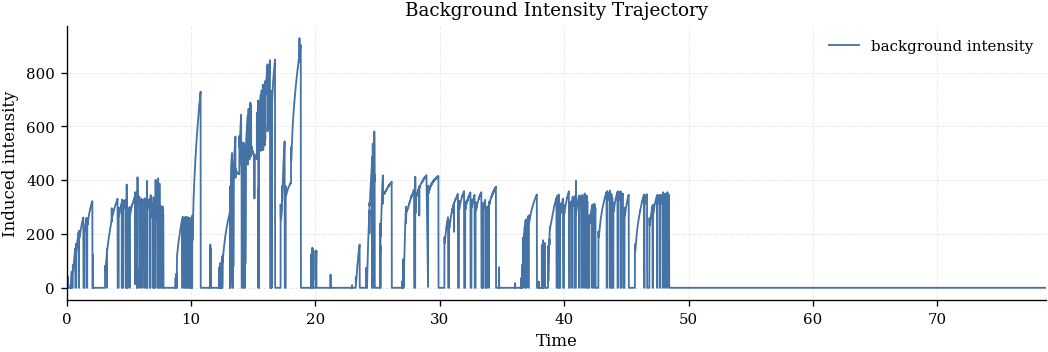

In [49]:
if getattr(model, 'bg_model', None) is None:
    print('Skip background intensity plot: model has no bg_model.')
else:
    with torch.no_grad():
        f_intensity_trajectory = model.bg_model.intensity_trajectory(batch)

    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        batch.time_series_times.squeeze().detach().cpu().numpy(),
        f_intensity_trajectory.squeeze().detach().cpu().numpy(),
        linewidth=1.1,
        color=diag_colors['bg'],
        label='background intensity',
    )
    _apply_diag_axis(ax, ylabel='Induced intensity', title='Background Intensity Trajectory')
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'induced_intensity_diagnostics.png', file_format='png')
    plt.show()


In [50]:
if getattr(model, 'bg_model', None) is None:
    print('Skip gate plot: model has no bg_model.')
elif not hasattr(model.bg_model, 'gate_trajectory'):
    print('Skip gate plot: background model does not expose gate_trajectory().')
else:
    with torch.no_grad():
        gate_times, gate_weights = model.bg_model.gate_trajectory(batch)

    batch_idx = 0
    gate_times_tensor = gate_times.detach()
    gate_weights_tensor = gate_weights.detach()
    if gate_times_tensor.ndim >= 2:
        gate_times_tensor = gate_times_tensor[batch_idx]
    if gate_weights_tensor.ndim >= 3:
        gate_weights_tensor = gate_weights_tensor[batch_idx]

    gate_times_np = gate_times_tensor.cpu().numpy().reshape(-1)
    gate_weights_np = gate_weights_tensor.cpu().numpy()
    if gate_weights_np.ndim == 1:
        gate_weights_np = gate_weights_np.reshape(-1, 1)
    elif gate_weights_np.ndim > 2:
        gate_weights_np = gate_weights_np.reshape(gate_weights_np.shape[0], -1)

    n_points = min(gate_times_np.shape[0], gate_weights_np.shape[0])
    gate_times_np = gate_times_np[:n_points]
    gate_weights_np = gate_weights_np[:n_points]

    valid_mask = np.isfinite(gate_times_np) & np.all(np.isfinite(gate_weights_np), axis=1)
    ts_mask = getattr(batch, 'time_series_mask', None)
    if ts_mask is not None:
        ts_mask_np = ts_mask.detach().cpu().numpy()
        if ts_mask_np.ndim >= 2:
            ts_mask_np = ts_mask_np[batch_idx]
        ts_mask_np = ts_mask_np.reshape(-1).astype(bool)[:n_points]
        if ts_mask_np.shape[0] == n_points:
            valid_mask &= ts_mask_np

    gate_times_np = gate_times_np[valid_mask]
    gate_weights_np = gate_weights_np[valid_mask]

    if gate_times_np.size == 0:
        print('Skip gate plot: no valid gate time points.')
    else:
        order = np.argsort(gate_times_np)
        gate_times_np = gate_times_np[order]
        gate_weights_np = gate_weights_np[order]

        n_experts = gate_weights_np.shape[-1]
        if n_experts == 0:
            print('Skip gate plot: gate_trajectory returned no experts.')
        else:
            expert_names = list(getattr(model.bg_model, 'expert_names', []))
            if len(expert_names) > n_experts:
                expert_names = expert_names[:n_experts]
            if len(expert_names) != n_experts:
                kernel_types = list(getattr(model.bg_model, 'kernel_types', []))
                expert_names = kernel_types if len(kernel_types) == n_experts else []
            if len(expert_names) != n_experts:
                expert_names = [f'expert_{idx}' for idx in range(n_experts)]

            # Choose a discrete colormap so expert colors do not accidentally repeat.
            if n_experts <= 10:
                cmap_name = 'tab10'
            elif n_experts <= 20:
                cmap_name = 'tab20'
            else:
                cmap_name = 'gist_rainbow'
            cmap = plt.get_cmap(cmap_name, n_experts)
            colors = [cmap(idx) for idx in range(n_experts)]

            legend_ncol = min(n_experts, 4)
            legend_rows = int(np.ceil(n_experts / legend_ncol))
            bottom_margin = min(0.16 + 0.055 * legend_rows, 0.45)
            fig_height = 3.5 + 0.22 * max(legend_rows - 1, 0)

            fig, ax = plt.subplots(figsize=(9.5, fig_height))
            for idx, expert_name in enumerate(expert_names):
                ax.plot(
                    gate_times_np,
                    gate_weights_np[:, idx],
                    linewidth=1.25,
                    color=colors[idx],
                    label=expert_name,
                )

            ax.set_xlim(float(gate_times_np.min()), float(gate_times_np.max()))
            if np.nanmin(gate_weights_np) >= -1e-6 and np.nanmax(gate_weights_np) <= 1.0 + 1e-6:
                ax.set_ylim(-0.02, 1.02)
            else:
                ax.margins(y=0.06)
            ax.set_xlabel('Time')
            ax.set_ylabel('Gate weight')

            bg_cls_name = type(model.bg_model).__name__
            ax.set_title(f'{bg_cls_name} Gate Weights Over Time')
            ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            handles, labels = ax.get_legend_handles_labels()
            if handles:
                fig.legend(
                    handles,
                    labels,
                    frameon=False,
                    ncol=legend_ncol,
                    loc='lower center',
                    bbox_to_anchor=(0.5, 0.02),
                    handlelength=1.8,
                    columnspacing=1.1,
                )

            fig.tight_layout(rect=(0.0, bottom_margin, 1.0, 1.0))
            save_pub_figure(fig, CHECKPOINT_DIR / 'mamba_moe_gate_weights.png', file_format='png')
            plt.show()


Skip gate plot: background model does not expose gate_trajectory().


## 5) KernelMamba Decomposition and Gate Analysis

These cells are active only when `model.bg_model` is `KernelMambaBGModel`. They inspect learned kernels, signed components, gate specialization, and synthetic-probe component responses.


In [51]:
bg_model = getattr(model, 'bg_model', None)
is_kernel_mamba = bg_model is not None and type(bg_model).__name__ == 'KernelMambaBGModel'


def _display_table(table):
    try:
        display(table)
    except NameError:
        print(table.to_string(index=False))


def _tensor_scalar(value):
    if value is None:
        return None
    if torch.is_tensor(value):
        return float(value.detach().cpu().reshape(-1)[0].item())
    return float(value)


def _first_valid_time_matrix(times_tensor, values_tensor, *, batch_obj=batch, batch_idx=0):
    times_tensor = times_tensor.detach()
    values_tensor = values_tensor.detach()
    times_have_batch = times_tensor.ndim >= 2
    if times_have_batch:
        times_tensor = times_tensor[batch_idx]
    if values_tensor.ndim >= 3:
        values_tensor = values_tensor[batch_idx]
    elif values_tensor.ndim == 2 and times_have_batch:
        values_tensor = values_tensor[batch_idx]

    times_np = times_tensor.cpu().numpy().reshape(-1)
    values_np = values_tensor.cpu().numpy()
    if values_np.ndim == 1:
        values_np = values_np.reshape(-1, 1)
    elif values_np.ndim > 2:
        values_np = values_np.reshape(values_np.shape[0], -1)

    n_points = min(times_np.shape[0], values_np.shape[0])
    times_np = times_np[:n_points]
    values_np = values_np[:n_points]

    valid_mask = np.isfinite(times_np) & np.all(np.isfinite(values_np), axis=1)
    ts_mask = getattr(batch_obj, 'time_series_mask', None)
    if ts_mask is not None:
        ts_mask_np = ts_mask.detach().cpu().numpy()
        if ts_mask_np.ndim >= 2:
            ts_mask_np = ts_mask_np[batch_idx]
        ts_mask_np = ts_mask_np.reshape(-1).astype(bool)[:n_points]
        if ts_mask_np.shape[0] == n_points:
            valid_mask &= ts_mask_np

    times_np = times_np[valid_mask]
    values_np = values_np[valid_mask]
    if times_np.size == 0:
        return times_np, values_np

    order = np.argsort(times_np)
    return times_np[order], values_np[order]


def _integrate_over_time(values_np, times_np):
    values_np = np.asarray(values_np, dtype=float)
    times_np = np.asarray(times_np, dtype=float)
    if values_np.size == 0:
        return float('nan')
    if values_np.size == 1:
        return float(values_np.reshape(-1)[0])
    return float(np.trapz(values_np, times_np))


if bg_model is None:
    print('Skip KernelMamba summary: model has no bg_model.')
elif not is_kernel_mamba:
    print(f'Skip KernelMamba summary: bg_model is {type(bg_model).__name__}.')
else:
    summary_rows = [
        ('class', type(bg_model).__name__),
        ('kernel_types', ', '.join(map(str, getattr(bg_model, 'kernel_types', [])))),
        ('expert_names', ', '.join(map(str, getattr(bg_model, 'expert_names', [])))),
        ('gate_type', getattr(bg_model, 'gate_type', None)),
        ('gate_temperature', getattr(bg_model, 'gate_temperature', None)),
        ('kernel_activation', getattr(bg_model, 'kernel_activation', None)),
        ('residual_activation', getattr(bg_model, 'residual_activation', None)),
        ('global_scale', _tensor_scalar(getattr(bg_model, '_scale', None))),
        ('kernel_weight', _tensor_scalar(getattr(bg_model, 'kernel_weight', None))),
        ('residual_weight', _tensor_scalar(getattr(bg_model, 'residual_weight', None))),
        ('residual_penalty_weight', getattr(bg_model, 'residual_penalty_weight', None)),
        ('gate_smooth_weight', getattr(bg_model, 'gate_smooth_weight', None)),
        ('gate_entropy_weight', getattr(bg_model, 'gate_entropy_weight', None)),
    ]

    with torch.no_grad():
        if hasattr(bg_model, 'residual_ratio'):
            residual_ratio = bg_model.residual_ratio(batch)
            summary_rows.append(('residual_abs_share(batch)', float(residual_ratio.detach().cpu().mean().item())))
        if hasattr(bg_model, 'kl_term'):
            kl_value = bg_model.kl_term(batch)
            summary_rows.append(('regularizer_kl_term(batch)', float(kl_value.detach().cpu().mean().item())))

    summary_df = pd.DataFrame(summary_rows, columns=['metric', 'value'])
    _display_table(summary_df)


Skip KernelMamba summary: bg_model is MambaBGModel.


In [52]:
if not is_kernel_mamba or not hasattr(bg_model, 'kernel_modules'):
    print('Skip kernel-shape diagnostics: bg_model is not KernelMambaBGModel or has no kernel_modules.')
else:
    kernel_names = list(getattr(bg_model, 'kernel_types', []))
    if len(kernel_names) != len(bg_model.kernel_modules):
        kernel_names = [f'kernel_{idx}' for idx in range(len(bg_model.kernel_modules))]

    kernel_rows = []
    fig, ax = plt.subplots(figsize=(8.8, 3.6))
    for idx, (kernel_name, kernel_module) in enumerate(zip(kernel_names, bg_model.kernel_modules)):
        with torch.no_grad():
            kernel_tensor = kernel_module(device=DEVICE, dtype=torch.float32)
        kernel_np = kernel_tensor.detach().cpu().numpy().reshape(-1)
        dt_value = float(getattr(kernel_module, 'dt', 1.0))
        lag_np = np.arange(kernel_np.size, dtype=float) * dt_value
        kernel_mass = float(kernel_np.sum())
        mean_lag = float((lag_np * kernel_np).sum() / max(kernel_mass, 1e-12))
        std_lag = float(np.sqrt((((lag_np - mean_lag) ** 2) * kernel_np).sum() / max(kernel_mass, 1e-12)))
        peak_idx = int(np.argmax(kernel_np)) if kernel_np.size else -1

        kernel_rows.append({
            'kernel': kernel_name,
            'mass': kernel_mass,
            'peak_lag': float(lag_np[peak_idx]) if peak_idx >= 0 else np.nan,
            'peak_value': float(kernel_np[peak_idx]) if peak_idx >= 0 else np.nan,
            'mean_lag': mean_lag,
            'std_lag': std_lag,
        })
        ax.plot(lag_np, kernel_np, linewidth=1.3, label=kernel_name)

    ax.set_xlabel('Lag')
    ax.set_ylabel('Kernel weight')
    ax.set_title('KernelMamba Learned Kernel Shapes')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, ncol=min(len(kernel_names), 4))
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'kernel_mamba_kernel_shapes.png', file_format='png')
    plt.show()

    _display_table(pd.DataFrame(kernel_rows))


Skip kernel-shape diagnostics: bg_model is not KernelMambaBGModel or has no kernel_modules.


In [53]:
if not is_kernel_mamba or not hasattr(bg_model, 'component_trajectory'):
    print('Skip component decomposition: bg_model does not expose component_trajectory().')
else:
    with torch.no_grad():
        component_times, components = bg_model.component_trajectory(batch)

    component_times_np, components_np = _first_valid_time_matrix(component_times, components, batch_obj=batch)

    if component_times_np.size == 0:
        print('Skip component decomposition: no valid time points.')
    else:
        component_names = list(getattr(bg_model, 'expert_names', []))
        if len(component_names) != components_np.shape[-1]:
            component_names = [f'component_{idx}' for idx in range(components_np.shape[-1])]

        signed_total_np = components_np.sum(axis=1)
        negative_fraction = float(np.mean(signed_total_np < 0.0))
        negative_area = _integrate_over_time(np.maximum(-signed_total_np, 0.0), component_times_np)
        positive_area = _integrate_over_time(np.maximum(signed_total_np, 0.0), component_times_np)

        print(f'signed total negative fraction: {negative_fraction:.2%}')
        print(f'negative signed-total area: {negative_area:.6g}')
        print(f'positive signed-total area: {positive_area:.6g}')

        total_abs_area = sum(
            max(_integrate_over_time(np.abs(components_np[:, idx]), component_times_np), 0.0)
            for idx in range(components_np.shape[-1])
        )
        component_rows = []
        for idx, component_name in enumerate(component_names):
            component_values = components_np[:, idx]
            signed_area = _integrate_over_time(component_values, component_times_np)
            abs_area = _integrate_over_time(np.abs(component_values), component_times_np)
            component_rows.append({
                'component': component_name,
                'signed_area': signed_area,
                'abs_area': abs_area,
                'abs_share': abs_area / max(total_abs_area, 1e-12),
                'mean': float(np.mean(component_values)),
                'min': float(np.min(component_values)),
                'max': float(np.max(component_values)),
                'negative_fraction': float(np.mean(component_values < 0.0)),
            })
        component_df = pd.DataFrame(component_rows)
        _display_table(component_df)

        colors = plt.get_cmap('tab20', max(components_np.shape[-1], 1))
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12.2, 4.4),
            constrained_layout=True,
            gridspec_kw={'width_ratios': [2.4, 1.0]},
        )

        for idx, component_name in enumerate(component_names):
            axes[0].plot(
                component_times_np,
                components_np[:, idx],
                linewidth=1.05,
                color=colors(idx),
                label=component_name,
            )
        axes[0].plot(
            component_times_np,
            signed_total_np,
            color='#111111',
            linewidth=1.35,
            linestyle='--',
            label='sum components',
        )
        axes[0].axhline(0.0, color='black', linewidth=0.8, alpha=0.65)
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Signed component')
        axes[0].set_title('KernelMamba Signed Components')
        axes[0].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        axes[0].spines['top'].set_visible(False)
        axes[0].spines['right'].set_visible(False)
        axes[0].legend(
            frameon=False,
            ncol=min(len(component_names) + 1, 4),
            loc='upper center',
            bbox_to_anchor=(0.5, -0.16),
            handlelength=1.8,
            columnspacing=1.0,
        )

        share_values = component_df['abs_share'].to_numpy(dtype=float)
        y_pos = np.arange(len(component_df))
        axes[1].barh(
            y_pos,
            share_values,
            color=[colors(idx) for idx in range(len(component_df))],
            alpha=0.9,
        )
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(component_df['component'].tolist())
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Abs. contribution share')
        axes[1].set_title('Integrated |component| share')
        axes[1].grid(True, axis='x', alpha=0.25, linestyle='--', linewidth=0.6)
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)
        x_max = max(0.05, float(np.nanmax(share_values)) * 1.18) if share_values.size else 1.0
        axes[1].set_xlim(0.0, x_max)
        for row_idx, share in enumerate(share_values):
            axes[1].text(
                share + x_max * 0.02,
                row_idx,
                f'{share:.1%}',
                va='center',
                fontsize=8,
            )

        save_pub_figure(fig, CHECKPOINT_DIR / 'kernel_mamba_component_decomposition.png', file_format='png')
        plt.show()


Skip component decomposition: bg_model does not expose component_trajectory().


In [54]:
if not is_kernel_mamba or not hasattr(bg_model, 'gate_trajectory'):
    print('Skip KernelMamba gate diagnostics: bg_model does not expose gate_trajectory().')
else:
    with torch.no_grad():
        gate_times, gate_weights = bg_model.gate_trajectory(batch)
    gate_times_np, gate_weights_np = _first_valid_time_matrix(gate_times, gate_weights, batch_obj=batch)

    if gate_times_np.size == 0 or gate_weights_np.shape[-1] == 0:
        print('Skip KernelMamba gate diagnostics: no valid gate values.')
    else:
        n_experts = gate_weights_np.shape[-1]
        gate_names = list(getattr(bg_model, 'kernel_types', []))
        if len(gate_names) != n_experts:
            gate_names = list(getattr(bg_model, 'expert_names', []))[:n_experts]
        if len(gate_names) != n_experts:
            gate_names = [f'gate_{idx}' for idx in range(n_experts)]

        gate_safe_np = np.clip(gate_weights_np, 1e-12, None)
        gate_entropy_np = -(gate_safe_np * np.log(gate_safe_np)).sum(axis=1)
        if n_experts > 1:
            gate_entropy_norm_np = gate_entropy_np / np.log(n_experts)
        else:
            gate_entropy_norm_np = np.zeros_like(gate_entropy_np)
        dominant_idx_np = np.argmax(gate_weights_np, axis=1)

        gate_rows = []
        for idx, gate_name in enumerate(gate_names):
            gate_values = gate_weights_np[:, idx]
            gate_rows.append({
                'expert': gate_name,
                'mean_gate': float(np.mean(gate_values)),
                'std_gate': float(np.std(gate_values)),
                'min_gate': float(np.min(gate_values)),
                'max_gate': float(np.max(gate_values)),
                'dominant_fraction': float(np.mean(dominant_idx_np == idx)),
            })
        print(f'normalized gate entropy: mean={gate_entropy_norm_np.mean():.4f}, min={gate_entropy_norm_np.min():.4f}, max={gate_entropy_norm_np.max():.4f}')
        _display_table(pd.DataFrame(gate_rows))

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(10.0, 7.2),
            sharex=True,
            constrained_layout=True,
            gridspec_kw={'height_ratios': [2.2, 1.0, 1.0]},
        )
        heatmap = axes[0].imshow(
            gate_weights_np.T,
            aspect='auto',
            interpolation='nearest',
            extent=[float(gate_times_np.min()), float(gate_times_np.max()), n_experts - 0.5, -0.5],
            cmap='viridis',
            vmin=0.0,
            vmax=1.0 if np.nanmax(gate_weights_np) <= 1.0 + 1e-6 else None,
        )
        axes[0].set_yticks(np.arange(n_experts))
        axes[0].set_yticklabels(gate_names)
        axes[0].set_ylabel('Expert')
        axes[0].set_title('KernelMamba Gate Heatmap')
        fig.colorbar(heatmap, ax=axes[0], pad=0.01, label='Gate weight')

        axes[1].plot(gate_times_np, gate_entropy_norm_np, color='#d62728', linewidth=1.2)
        axes[1].set_ylabel('Norm. entropy')
        axes[1].set_ylim(-0.03, 1.03)
        axes[1].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)

        axes[2].step(gate_times_np, dominant_idx_np, where='post', color='#1f77b4', linewidth=1.2)
        axes[2].set_yticks(np.arange(n_experts))
        axes[2].set_yticklabels(gate_names)
        axes[2].set_ylabel('Dominant')
        axes[2].set_xlabel('Time')
        axes[2].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        axes[2].spines['top'].set_visible(False)
        axes[2].spines['right'].set_visible(False)

        save_pub_figure(fig, CHECKPOINT_DIR / 'kernel_mamba_gate_diagnostics.png', file_format='png')
        plt.show()


Skip KernelMamba gate diagnostics: bg_model does not expose gate_trajectory().


In [55]:
if not is_kernel_mamba or not hasattr(bg_model, 'component_trajectory'):
    print('Skip KernelMamba probe component diagnostics: bg_model does not expose component_trajectory().')
else:
    base_times = batch.time_series_times.detach()
    if base_times.ndim >= 2:
        base_times = base_times[0]
    base_times = base_times.reshape(-1).to(DEVICE)
    ts_mask = getattr(batch, 'time_series_mask', None)
    if ts_mask is not None:
        base_mask = ts_mask.detach()
        if base_mask.ndim >= 2:
            base_mask = base_mask[0]
        base_mask = base_mask.reshape(-1).to(device=DEVICE, dtype=torch.bool)
        n_mask_points = min(base_times.numel(), base_mask.numel())
        base_times = base_times[:n_mask_points][base_mask[:n_mask_points]]
    base_times, _ = torch.sort(base_times)

    if base_times.numel() == 0:
        print('Skip KernelMamba probe component diagnostics: no valid probe times.')
    else:
        start_time = float(base_times.min().item())
        end_time = float(base_times.max().item())
        time_span = max(end_time - start_time, 1e-8)
        normalized_time = (base_times - start_time) / time_span
        d_feature = int(getattr(bg_model, 'd_feature', batch.time_series.shape[-1]))

        probe_series = {
            'zero_input': torch.zeros_like(normalized_time),
            'step_mid': torch.where(normalized_time >= 0.1, torch.tensor(0.3, device=DEVICE), torch.tensor(0.0, device=DEVICE)),
            'single_pulse': torch.where((normalized_time >= 0.40) & (normalized_time <= 0.50), torch.tensor(1.2, device=DEVICE), torch.tensor(0.0, device=DEVICE)),
            'linear_ramp': normalized_time,
            'periodic_sine': 0.6 * (torch.sin(2 * torch.pi * 3 * normalized_time) + 1.0),
        }

        component_names = list(getattr(bg_model, 'expert_names', []))
        colors = plt.get_cmap('tab20', max(len(component_names), 1))
        fig, axes = plt.subplots(len(probe_series), 3, figsize=(14.0, 2.5 * len(probe_series)), sharex='col')
        if len(probe_series) == 1:
            axes = np.array([axes])

        for row_idx, (probe_name, first_feature_values) in enumerate(probe_series.items()):
            probe_values = torch.zeros(base_times.numel(), d_feature, device=DEVICE, dtype=torch.float32)
            probe_values[:, 0] = first_feature_values.to(dtype=torch.float32)

            probe_batch = sequence_to_batch(seq, DEVICE)
            probe_batch.time_series_times = base_times.unsqueeze(0)
            probe_batch.time_series = probe_values.unsqueeze(0)
            probe_batch.time_series_mask = torch.ones(1, base_times.numel(), device=DEVICE, dtype=torch.bool)

            with torch.no_grad():
                component_times, components = bg_model.component_trajectory(probe_batch)
                final_response = bg_model.intensity_trajectory(probe_batch)

            time_np, components_np = _first_valid_time_matrix(component_times, components, batch_obj=probe_batch)
            _, final_response_np = _first_valid_time_matrix(component_times, final_response, batch_obj=probe_batch)
            final_response_np = final_response_np.reshape(-1)[:time_np.size]
            input_np = first_feature_values.detach().cpu().numpy()[:time_np.size]

            if len(component_names) != components_np.shape[-1]:
                plot_component_names = [f'component_{idx}' for idx in range(components_np.shape[-1])]
            else:
                plot_component_names = component_names

            input_axis, total_axis, component_axis = axes[row_idx]
            input_axis.plot(time_np, input_np, color='#1f77b4', linewidth=1.1)
            input_axis.set_ylabel(probe_name)
            input_axis.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
            input_axis.spines['top'].set_visible(False)
            input_axis.spines['right'].set_visible(False)

            total_axis.plot(time_np, final_response_np, color='#111111', linewidth=1.2)
            total_axis.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
            total_axis.spines['top'].set_visible(False)
            total_axis.spines['right'].set_visible(False)
            for component_idx, component_name in enumerate(plot_component_names):
                component_axis.plot(
                    time_np,
                    components_np[:, component_idx],
                    color=colors(component_idx),
                    linewidth=0.95,
                    label=component_name,
                )
            component_axis.axhline(0.0, color='black', linewidth=0.7, alpha=0.6)
            component_axis.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
            component_axis.spines['top'].set_visible(False)
            component_axis.spines['right'].set_visible(False)
            if row_idx == 0:
                component_axis.legend(frameon=False, ncol=min(len(plot_component_names), 4), loc='upper left', bbox_to_anchor=(1.0, 1.0))

        axes[0, 0].set_title('Synthetic input')
        axes[0, 1].set_title('Final response')
        axes[0, 2].set_title('Signed components')
        axes[-1, 0].set_xlabel('Time')
        axes[-1, 1].set_xlabel('Time')
        axes[-1, 2].set_xlabel('Time')

        fig.tight_layout()
        save_pub_figure(fig, CHECKPOINT_DIR / 'kernel_mamba_probe_component_responses.png', file_format='png')
        plt.show()


Skip KernelMamba probe component diagnostics: bg_model does not expose component_trajectory().


## 6) S4D Kernel and Time-Scale Interpretability

S4D is especially interpretable because each hidden channel is a diagonal linear state-space system before the pointwise nonlinearity/output mixing. The learned convolution kernel is the impulse response:

$$K_h[t] = 2\operatorname{Re}\sum_n \bar{C}_{h,n}\exp(t\,\Delta_h A_{h,n}),\quad A_{h,n}=-\exp(\theta_{h,n}) + i\omega_{h,n}.$$

Interpretation checklist used below:
- **Kernel heatmap**: rows are hidden channels; bright late lags mean long-memory response. This follows the kernel visualizations used in DSS/S4D analyses.
- **Peak lag and mass horizons**: `peak_lag`, `t50`, `t90`, `t95` summarize delay and memory length from `|K|` cumulative mass.
- **Pole/time-scale map**: `Re(A)` gives decay, `Im(A)` gives oscillatory period, and learned `dt` rescales both. For this implementation, half-life in sequence steps is approximately `log(2) / (dt * exp(log_A_real))`.
- **Full-model impulse response**: probes `bg_model` after `fc_in`, S4D, nonlinearities, output projection, scaling, and clamping; it explains the actual background-intensity effect, not just the raw S4D layer.

References: Gupta et al. (2022), *Diagonal State Spaces are as Effective as Structured State Spaces*; Gu et al. (2022), *On the Parameterization and Initialization of Diagonal State Space Models*; and the official `state-spaces/s4` implementation notes.


In [56]:
def _find_s4d_layer(module):
    if module is None:
        return None
    if module.__class__.__name__.lower() == 's4d' and hasattr(module, 'kernel'):
        return module
    direct = getattr(module, 's4d', None)
    if direct is not None and hasattr(direct, 'kernel'):
        return direct
    if hasattr(module, 'named_modules'):
        for _, child in module.named_modules():
            if child is module:
                continue
            if child.__class__.__name__.lower() == 's4d' and hasattr(child, 'kernel'):
                return child
    return None


def _first_crossing(cum_mass: torch.Tensor, threshold: float) -> torch.Tensor:
    hits = cum_mass >= threshold
    first = hits.float().argmax(dim=1)
    no_hit = ~hits.any(dim=1)
    if no_hit.any():
        first = first.clone()
        first[no_hit] = cum_mass.shape[1] - 1
    return first


bg_model = getattr(model, 'bg_model', None)
s4d_layer = _find_s4d_layer(bg_model)
S4D_INTERP = {}

if s4d_layer is None:
    print('Skip S4D diagnostics: current background model does not expose an S4D layer.')
else:
    s4d_layer.eval()
    T_observed = int(batch.time_series.shape[1])
    S4D_KERNEL_MAX_LEN = 2048
    kernel_length = max(8, min(T_observed, S4D_KERNEL_MAX_LEN))

    with torch.no_grad():
        K = s4d_layer.kernel(kernel_length, dtype=torch.float32).detach().cpu()  # (d_model, L)

    K_abs = K.abs()
    K_abs_sum = K_abs.sum(dim=1, keepdim=True).clamp_min(1e-12)
    K_mass = K_abs / K_abs_sum
    K_cum = K_mass.cumsum(dim=1)
    peak_idx = K_abs.argmax(dim=1)
    t50_idx = _first_crossing(K_cum, 0.50)
    t90_idx = _first_crossing(K_cum, 0.90)
    t95_idx = _first_crossing(K_cum, 0.95)

    time_grid = batch.time_series_times[0].detach().cpu().reshape(-1)
    if time_grid.numel() > 1:
        median_grid_dt = float(torch.median(time_grid[1:] - time_grid[:-1]).item())
        if not np.isfinite(median_grid_dt) or median_grid_dt <= 0:
            median_grid_dt = 1.0
    else:
        median_grid_dt = 1.0
    lag_steps = np.arange(kernel_length)
    lag_time = lag_steps * median_grid_dt
    lag_label = f'Lag (steps; approx {median_grid_dt:.4g} time units/step)'

    channel_df = pd.DataFrame({
        'channel': np.arange(K.shape[0]),
        'peak_lag_step': peak_idx.numpy(),
        't50_step': t50_idx.numpy(),
        't90_step': t90_idx.numpy(),
        't95_step': t95_idx.numpy(),
        'peak_lag_time': peak_idx.numpy() * median_grid_dt,
        't50_time': t50_idx.numpy() * median_grid_dt,
        't90_time': t90_idx.numpy() * median_grid_dt,
        't95_time': t95_idx.numpy() * median_grid_dt,
        'signed_area': K.sum(dim=1).numpy(),
        'abs_area': K_abs.sum(dim=1).numpy(),
        'tail_mass_second_half': K_mass[:, kernel_length // 2:].sum(dim=1).numpy(),
    })
    summary = channel_df[[
        'peak_lag_step', 't50_step', 't90_step', 't95_step',
        'peak_lag_time', 't50_time', 't90_time', 't95_time',
        'tail_mass_second_half',
    ]].describe(percentiles=[0.1, 0.5, 0.9]).T

    print(f'S4D layer found: d_model={K.shape[0]}, kernel_length={kernel_length}')
    print('Kernel/memory summary across hidden channels:')
    display(summary)
    print('Channels with largest t95 memory horizon:')
    display(channel_df.sort_values('t95_step', ascending=False).head(10))

    order = np.argsort(channel_df['peak_lag_step'].to_numpy())
    K_heat = K_abs.numpy()[order]
    K_heat = K_heat / np.maximum(K_heat.max(axis=1, keepdims=True), 1e-12)
    mean_abs = K_abs.mean(dim=0).numpy()
    q25 = torch.quantile(K_abs, 0.25, dim=0).numpy()
    q75 = torch.quantile(K_abs, 0.75, dim=0).numpy()
    mean_cum = K_cum.mean(dim=0).numpy()

    fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.2), constrained_layout=True)

    im = axes[0, 0].imshow(
        K_heat,
        aspect='auto',
        interpolation='nearest',
        extent=[lag_time[0], lag_time[-1], K_heat.shape[0], 0],
        cmap='magma',
        vmin=0.0,
        vmax=1.0,
    )
    axes[0, 0].set_title('S4D normalized |kernel| heatmap\n(rows sorted by peak lag)')
    axes[0, 0].set_xlabel(lag_label)
    axes[0, 0].set_ylabel('Hidden channel (sorted)')
    fig.colorbar(im, ax=axes[0, 0], label='|K| / max |K| per channel')

    axes[0, 1].plot(lag_time, mean_abs, color='#1f77b4', linewidth=1.2, label='mean |K|')
    axes[0, 1].fill_between(lag_time, q25, q75, color='#1f77b4', alpha=0.18, label='IQR across channels')
    axes[0, 1].set_yscale('log')
    axes[0, 1].set_title('Average kernel energy decay')
    axes[0, 1].set_xlabel(lag_label)
    axes[0, 1].set_ylabel('|K|')
    axes[0, 1].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    axes[0, 1].legend(frameon=False)

    axes[1, 0].plot(lag_time, mean_cum, color='#2ca02c', linewidth=1.4, label='mean cumulative |K| mass')
    for q, color in [(0.50, '#9467bd'), (0.90, '#ff7f0e'), (0.95, '#d62728')]:
        idx = int(np.argmax(mean_cum >= q)) if np.any(mean_cum >= q) else kernel_length - 1
        axes[1, 0].axhline(q, color=color, linestyle='--', linewidth=0.8, alpha=0.7)
        axes[1, 0].axvline(lag_time[idx], color=color, linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1, 0].text(lag_time[idx], q, f' {int(q * 100)}%', color=color, va='bottom', fontsize=8)
    axes[1, 0].set_ylim(0.0, 1.02)
    axes[1, 0].set_title('Cumulative memory mass')
    axes[1, 0].set_xlabel(lag_label)
    axes[1, 0].set_ylabel('Cumulative |K| mass')
    axes[1, 0].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)

    axes[1, 1].hist(channel_df['peak_lag_time'], bins=min(40, max(8, K.shape[0] // 2)), color='#4c78a8', alpha=0.82)
    axes[1, 1].set_title('Distribution of channel peak lags')
    axes[1, 1].set_xlabel(lag_label)
    axes[1, 1].set_ylabel('Channels')
    axes[1, 1].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)

    for ax in axes.ravel():
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('S4D Kernel Diagnostics: Delay and Memory Length', fontsize=12)
    save_pub_figure(fig, CHECKPOINT_DIR / 's4d_kernel_memory_diagnostics.png')
    plt.show()

    print('Interpretation: late bright bands, large t90/t95, or high second-half tail mass indicate long-memory channels.')
    print('If most mass is near lag 0, the trained S4D background behaves mostly like a short-response filter.')

    S4D_INTERP.update({
        'kernel': K,
        'kernel_abs': K_abs,
        'kernel_mass': K_mass,
        'kernel_cum': K_cum,
        'channel_df': channel_df,
        'kernel_length': kernel_length,
        'median_grid_dt': median_grid_dt,
        'lag_time': lag_time,
    })


Skip S4D diagnostics: current background model does not expose an S4D layer.


In [57]:
if s4d_layer is None:
    print('Skip S4D pole diagnostics: current background model does not expose an S4D layer.')
else:
    kmod = s4d_layer.kernel
    with torch.no_grad():
        dt = torch.exp(kmod.log_dt).detach().cpu()                    # (D,)
        decay = torch.exp(kmod.log_A_real).detach().cpu()             # positive, (D, N/2)
        omega = kmod.A_imag.detach().cpu().abs()                      # (D, N/2)
        A_bar, C_bar = kmod.discrete_parameters()
        C_strength = C_bar.detach().cpu().abs()                       # (D, N/2)

    decay_per_step = (dt.unsqueeze(-1) * decay).clamp_min(1e-12)
    half_life_steps = np.log(2.0) / decay_per_step
    angular_freq_per_step = dt.unsqueeze(-1) * omega
    period_steps = (2.0 * np.pi) / angular_freq_per_step.clamp_min(1e-12)
    period_steps = torch.where(angular_freq_per_step > 1e-8, period_steps, torch.full_like(period_steps, torch.nan))

    D, N = half_life_steps.shape
    channel_idx = torch.arange(D).unsqueeze(1).expand(D, N).reshape(-1).numpy()
    mode_idx = torch.arange(N).unsqueeze(0).expand(D, N).reshape(-1).numpy()
    pole_df = pd.DataFrame({
        'channel': channel_idx,
        'mode': mode_idx,
        'dt': dt.unsqueeze(1).expand(D, N).reshape(-1).numpy(),
        'decay_per_step': decay_per_step.reshape(-1).numpy(),
        'half_life_steps': half_life_steps.reshape(-1).numpy(),
        'period_steps': period_steps.reshape(-1).numpy(),
        'C_strength': C_strength.reshape(-1).numpy(),
    })
    print('S4D pole/time-scale summary:')
    display(pole_df[['dt', 'decay_per_step', 'half_life_steps', 'period_steps', 'C_strength']].describe(percentiles=[0.1, 0.5, 0.9]).T)

    finite = np.isfinite(pole_df['period_steps'].to_numpy())
    x = np.clip(pole_df['half_life_steps'].to_numpy(), 1e-8, None)
    y = pole_df['period_steps'].to_numpy()
    c = np.log10(np.clip(pole_df['C_strength'].to_numpy(), 1e-12, None))

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), constrained_layout=True)

    if finite.any():
        sc = axes[0].scatter(
            x[finite],
            y[finite],
            c=c[finite],
            s=10,
            alpha=0.72,
            cmap='viridis',
            linewidths=0,
        )
        fig.colorbar(sc, ax=axes[0], label='log10 |C_bar|')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Decay half-life (sequence steps)')
    axes[0].set_ylabel('Oscillation period (sequence steps)')
    axes[0].set_title('S4D pole map: decay vs oscillation')
    axes[0].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)

    log_half_life = np.log10(x)
    axes[1].hist(log_half_life, bins=40, color='#4c78a8', alpha=0.82)
    axes[1].set_xlabel('log10 half-life (steps)')
    axes[1].set_ylabel('Modes')
    axes[1].set_title('Distribution of learned decay horizons')
    axes[1].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('S4D Learned Poles and Time Scales', fontsize=12)
    save_pub_figure(fig, CHECKPOINT_DIR / 's4d_pole_timescale_map.png')
    plt.show()

    print('Interpretation: larger half-life means a mode can retain information over more sequence steps.')
    print('Small periods indicate oscillatory/alternating responses; NaN periods correspond to near-zero-frequency monotone modes.')
    S4D_INTERP['pole_df'] = pole_df


Skip S4D pole diagnostics: current background model does not expose an S4D layer.


In [58]:
if s4d_layer is None or getattr(model, 'bg_model', None) is None:
    print('Skip S4D full-model impulse response: current model has no S4D background layer.')
else:
    probe_times = batch.time_series_times.reshape(-1).detach().to(DEVICE)
    T = int(probe_times.numel())
    d_feature = int(getattr(model.bg_model, 'd_feature', batch.time_series.shape[-1]))
    observed_feature = batch.time_series[..., 0].detach().abs().reshape(-1)
    if observed_feature.numel() > 0:
        amplitude = float(torch.quantile(observed_feature, 0.95).item())
    else:
        amplitude = 1.0
    if not np.isfinite(amplitude) or amplitude <= 1e-8:
        amplitude = 1.0

    def _probe_response(values_1d: torch.Tensor) -> torch.Tensor:
        probe_batch = sequence_to_batch(seq, DEVICE)
        probe_batch.time_series_times = probe_times.unsqueeze(0)
        probe_ts = torch.zeros(1, T, d_feature, device=DEVICE, dtype=torch.float32)
        probe_ts[0, :, 0] = values_1d.to(device=DEVICE, dtype=torch.float32)
        probe_batch.time_series = probe_ts
        if hasattr(probe_batch, 'time_series_mask'):
            probe_batch.time_series_mask = torch.ones(1, T, device=DEVICE)
        with torch.no_grad():
            return model.bg_model.intensity_trajectory(probe_batch).reshape(-1)

    zeros = torch.zeros(T, device=DEVICE)
    impulse = torch.zeros(T, device=DEVICE)
    impulse[0] = amplitude
    pulse = torch.zeros(T, device=DEVICE)
    pulse[:max(1, T // 50)] = amplitude
    step = torch.full((T,), amplitude, device=DEVICE)

    baseline = _probe_response(zeros)
    impulse_delta = _probe_response(impulse) - baseline
    pulse_delta = _probe_response(pulse) - baseline
    step_delta = _probe_response(step) - baseline

    abs_impulse = impulse_delta.abs()
    peak_idx = int(abs_impulse.argmax().item())
    peak_time = float(probe_times[peak_idx].item())
    peak_value = float(impulse_delta[peak_idx].item())
    tail_start = max(1, int(0.75 * T))
    tail_ratio = float(abs_impulse[tail_start:].mean().item() / abs_impulse.max().clamp_min(1e-12).item())
    if T > 1:
        impulse_area = float(torch.trapz(impulse_delta, probe_times).item())
    else:
        impulse_area = float(impulse_delta.sum().item())

    t_np = probe_times.detach().cpu().numpy()
    fig, axes = plt.subplots(3, 1, figsize=(10.5, 8.0), sharex=True, constrained_layout=True)

    axes[0].plot(t_np, impulse.detach().cpu().numpy(), label='unit impulse', color='#1f77b4', linewidth=1.2)
    axes[0].plot(t_np, pulse.detach().cpu().numpy(), label='short pulse', color='#ff7f0e', linewidth=1.0, alpha=0.85)
    axes[0].plot(t_np, step.detach().cpu().numpy(), label='step', color='#2ca02c', linewidth=1.0, alpha=0.75)
    axes[0].set_ylabel('probe input')
    axes[0].set_title('Synthetic probes on feature 0')
    axes[0].legend(frameon=False, ncol=3)

    axes[1].plot(t_np, impulse_delta.detach().cpu().numpy(), color='#1f77b4', linewidth=1.2, label='impulse response delta')
    axes[1].plot(t_np, pulse_delta.detach().cpu().numpy(), color='#ff7f0e', linewidth=1.0, alpha=0.85, label='pulse response delta')
    axes[1].axhline(0.0, color='black', linewidth=0.8, alpha=0.7)
    axes[1].set_ylabel('delta intensity')
    axes[1].set_title('Full background-model impulse/pulse response')
    axes[1].legend(frameon=False)

    axes[2].plot(t_np, step_delta.detach().cpu().numpy(), color='#2ca02c', linewidth=1.2, label='step response delta')
    axes[2].axhline(0.0, color='black', linewidth=0.8, alpha=0.7)
    axes[2].set_ylabel('delta intensity')
    axes[2].set_xlabel('Time')
    axes[2].set_title('Full background-model step response')
    axes[2].legend(frameon=False)

    for ax in axes:
        ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('S4D Background Full-Model Probe Responses', fontsize=12)
    save_pub_figure(fig, CHECKPOINT_DIR / 's4d_full_bg_probe_response.png')
    plt.show()

    print(f'Probe amplitude from observed 95th percentile: {amplitude:.6g}')
    print(f'Impulse peak time: {peak_time:.6g}, peak delta intensity: {peak_value:.6g}')
    print(f'Impulse signed area: {impulse_area:.6g}')
    print(f'Late-tail mean/max ratio over final quarter: {tail_ratio:.6g}')
    print('Interpretation: delayed peaks indicate lagged triggering; slow decay or large late-tail ratio indicates persistent background memory.')
    print('This plot includes fc_in/fc_out, S4D nonlinearities, scale, and nonnegative intensity clamping, so it is closest to the deployed model behavior.')


Skip S4D full-model impulse response: current model has no S4D background layer.


## 7) Synthetic Time-Series Probes for Background Response


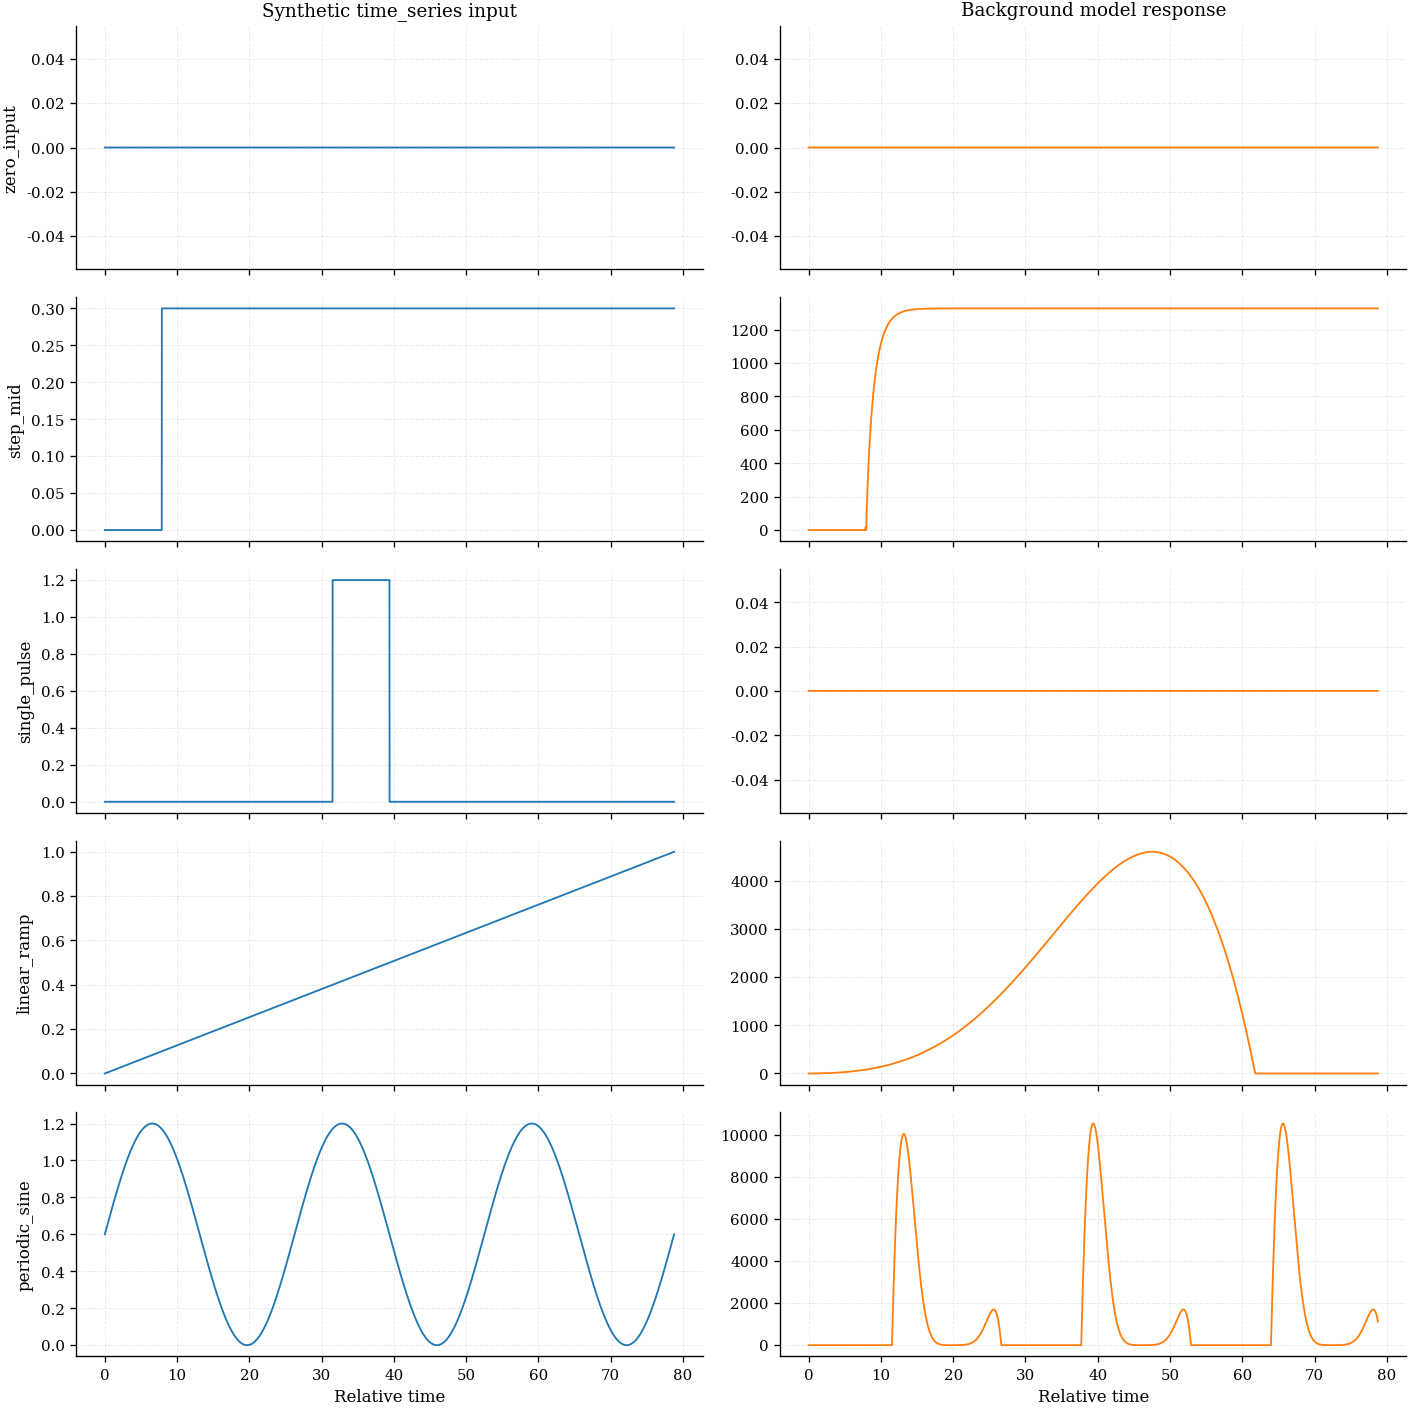

In [59]:
if getattr(model, 'bg_model', None) is None:
    print('Skip synthetic probe diagnostics: model has no bg_model.')
else:
    probe_times = batch.time_series_times.reshape(-1).detach().to(DEVICE)
    t0 = float(probe_times.min().item())
    t1 = float(probe_times.max().item())
    span = max(t1 - t0, 1e-8)

    x = (probe_times - t0) / span

    probe_series = {
        'zero_input': torch.zeros_like(x),
        'step_mid': torch.where(x >= 0.1, torch.tensor(0.3, device=DEVICE), torch.tensor(0.0, device=DEVICE)),
        'single_pulse': torch.where((x >= 0.40) & (x <= 0.50), torch.tensor(1.2, device=DEVICE), torch.tensor(0.0, device=DEVICE)),
        'linear_ramp': x,
        'periodic_sine': 0.6 * (torch.sin(2 * torch.pi * 3 * x) + 1.0),
    }

    fig, axes = plt.subplots(len(probe_series), 2, figsize=(12, 2.4 * len(probe_series)), sharex=True)
    if len(probe_series) == 1:
        axes = np.array([axes])

    for row_idx, (name, ts_values) in enumerate(probe_series.items()):
        probe_batch = sequence_to_batch(seq, DEVICE)
        probe_batch.time_series_times = probe_times.unsqueeze(0)
        probe_batch.time_series = ts_values.unsqueeze(0).unsqueeze(-1)

        with torch.no_grad():
            bg_response = model.bg_model.intensity_trajectory(probe_batch).reshape(-1)

        t_np = probe_times.detach().cpu().numpy()
        ts_np = ts_values.detach().cpu().numpy()
        bg_np = bg_response.detach().cpu().numpy()

        ax_l, ax_r = axes[row_idx]
        ax_l.plot(t_np, ts_np, color='#1f77b4', linewidth=1.1)
        ax_l.set_ylabel(name)
        ax_l.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        ax_l.spines['top'].set_visible(False)
        ax_l.spines['right'].set_visible(False)

        ax_r.plot(t_np, bg_np, color='#ff7f0e', linewidth=1.1)
        ax_r.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        ax_r.spines['top'].set_visible(False)
        ax_r.spines['right'].set_visible(False)

    axes[0, 0].set_title('Synthetic time_series input')
    axes[0, 1].set_title('Background model response')
    axes[-1, 0].set_xlabel('Relative time')
    axes[-1, 1].set_xlabel('Relative time')

    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'bg_response_synthetic_probes.png')
    plt.show()

## 8) Memory Effect Test: Keep vs Remove Previous Segment

Use the same second-segment input and compare background responses between:
- keep previous segment: first segment is a decaying signal;
- remove previous segment: first segment is replaced by zeros.

If responses differ on the second segment, the background model has path/history dependence.


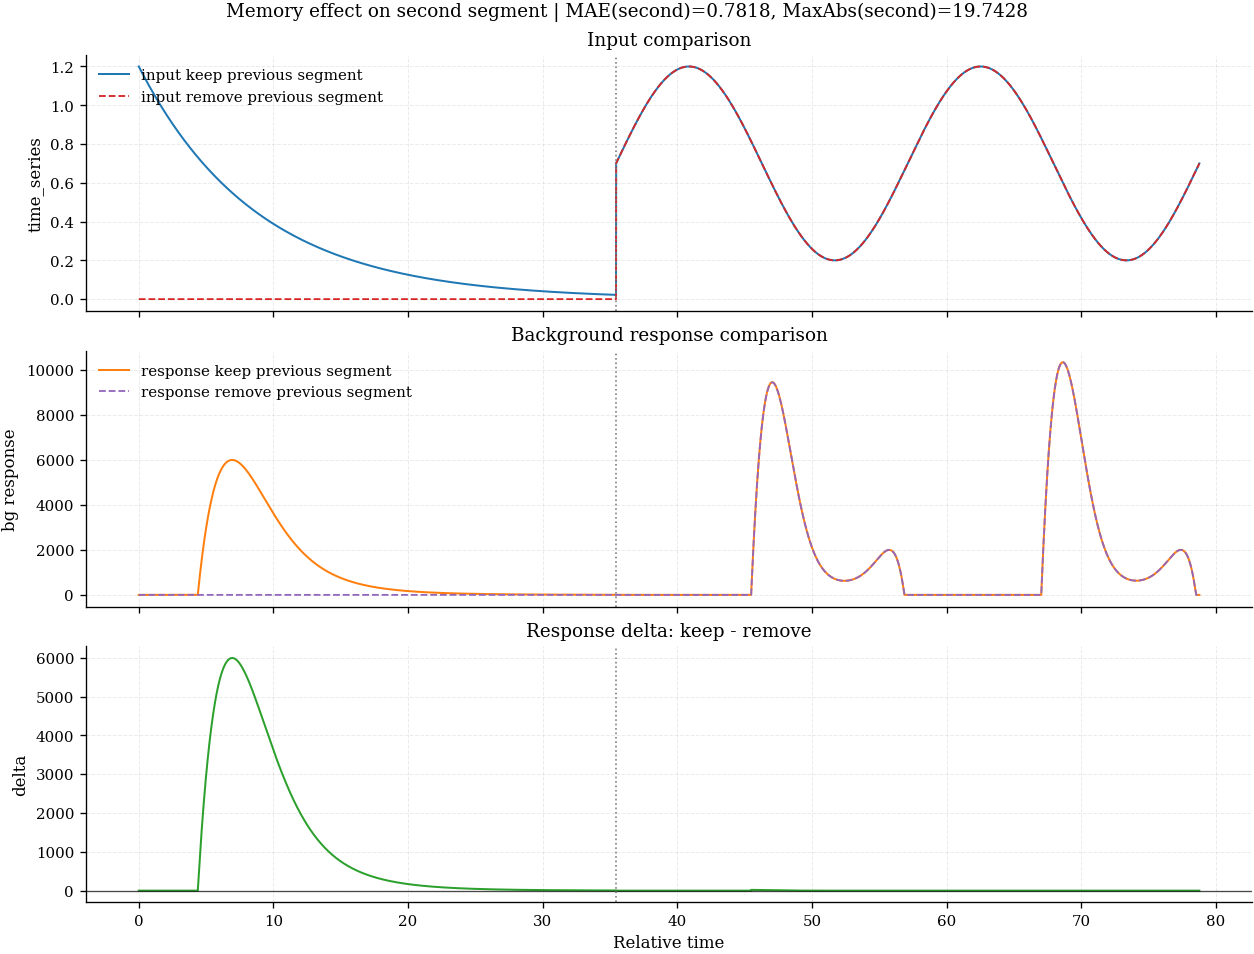

Second segment MAE (keep vs remove): 0.781779
Second segment MaxAbs diff: 19.742836
Interpretation: if both metrics are near 0, second-segment response is almost independent of previous segment.


In [60]:
if getattr(model, 'bg_model', None) is None:
    print('Skip memory-effect test: model has no bg_model.')
else:
    probe_times = batch.time_series_times.reshape(-1).detach().to(DEVICE)
    t0 = float(probe_times.min().item())
    t1 = float(probe_times.max().item())
    span = max(t1 - t0, 1e-8)
    x = (probe_times - t0) / span

    split_ratio = 0.45
    mask_first = x < split_ratio
    mask_second = ~mask_first

    # First segment: high-to-low exponential decay to near zero.
    tau = max(split_ratio * 0.25, 1e-4)
    first_decay = 1.2 * torch.exp(-x / tau)
    first_decay = torch.where(mask_first, first_decay, torch.tensor(0.0, device=DEVICE))

    # Second segment: fixed input used by both experiments.
    x2 = torch.clamp((x - split_ratio) / max(1.0 - split_ratio, 1e-8), min=0.0)
    second_segment = torch.where(mask_second, 0.7 + 0.5 * torch.sin(2 * torch.pi * 2 * x2), torch.tensor(0.0, device=DEVICE))

    ts_keep = first_decay + second_segment
    ts_remove = torch.where(mask_second, second_segment, torch.tensor(0.0, device=DEVICE))

    def run_bg_response(ts_values: torch.Tensor) -> torch.Tensor:
        probe_batch = sequence_to_batch(seq, DEVICE)
        probe_batch.time_series_times = probe_times.unsqueeze(0)
        probe_batch.time_series = ts_values.unsqueeze(0).unsqueeze(-1)
        with torch.no_grad():
            return model.bg_model.intensity_trajectory(probe_batch).reshape(-1)

    resp_keep = run_bg_response(ts_keep)
    resp_remove = run_bg_response(ts_remove)

    # Compare only on second segment.
    resp_keep_2 = resp_keep[mask_second]
    resp_remove_2 = resp_remove[mask_second]
    diff_2 = resp_keep_2 - resp_remove_2
    mae_2 = torch.mean(torch.abs(diff_2)).item()
    max_abs_2 = torch.max(torch.abs(diff_2)).item()

    t_np = probe_times.detach().cpu().numpy()
    ts_keep_np = ts_keep.detach().cpu().numpy()
    ts_remove_np = ts_remove.detach().cpu().numpy()
    resp_keep_np = resp_keep.detach().cpu().numpy()
    resp_remove_np = resp_remove.detach().cpu().numpy()

    fig, axes = plt.subplots(3, 1, figsize=(10.5, 8.0), sharex=True, constrained_layout=True)

    axes[0].plot(t_np, ts_keep_np, color='#1f77b4', linewidth=1.2, label='input keep previous segment')
    axes[0].plot(t_np, ts_remove_np, color='#d62728', linewidth=1.1, linestyle='--', label='input remove previous segment')
    axes[0].set_ylabel('time_series')
    axes[0].set_title('Input comparison')
    axes[0].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    axes[0].legend(frameon=False)

    axes[1].plot(t_np, resp_keep_np, color='#ff7f0e', linewidth=1.2, label='response keep previous segment')
    axes[1].plot(t_np, resp_remove_np, color='#9467bd', linewidth=1.1, linestyle='--', label='response remove previous segment')
    axes[1].set_ylabel('bg response')
    axes[1].set_title('Background response comparison')
    axes[1].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    axes[1].legend(frameon=False)

    diff_full = (resp_keep - resp_remove).detach().cpu().numpy()
    axes[2].plot(t_np, diff_full, color='#2ca02c', linewidth=1.2)
    axes[2].axhline(0.0, color='black', linewidth=0.8, alpha=0.7)
    axes[2].set_ylabel('delta')
    axes[2].set_xlabel('Relative time')
    axes[2].set_title('Response delta: keep - remove')
    axes[2].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)

    split_time = t0 + split_ratio * span
    for ax in axes:
        ax.axvline(split_time, color='gray', linewidth=1.0, linestyle=':')

    fig.suptitle(
        f'Memory effect on second segment | MAE(second)={mae_2:.4f}, MaxAbs(second)={max_abs_2:.4f}',
        fontsize=11,
    )
    save_pub_figure(fig, CHECKPOINT_DIR / 'bg_response_memory_effect_keep_vs_remove.png')
    plt.show()

    print(f'Second segment MAE (keep vs remove): {mae_2:.6f}')
    print(f'Second segment MaxAbs diff: {max_abs_2:.6f}')
    print('Interpretation: if both metrics are near 0, second-segment response is almost independent of previous segment.')